# 5. Diffcomp majortype

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import os
import cooler
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cm as cm
import seaborn as sns

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [2]:
group_name = 'all'

In [3]:
indir = f'{ENTEX_ROOT}/'
compdir = f'{indir}analysis/compartment/'
outdir = f'{indir}analysis/diff_comp/{group_name}/'


In [4]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
res = 100000

In [5]:
comp = pd.read_hdf(f'{compdir}L1/comp.impute.hdf')
comp

,chrom,start,end,raw_binfilter,c6,c3,c8,c20,c4,c9,...,c5,c12,c27,c21,c10,c7,c15,c24,c0,c1
0,chr1,0,100000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr1,100000,200000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,chr1,200000,300000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,chr1,300000,400000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr1,400000,500000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28755,chr22,50400000,50500000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28756,chr22,50500000,50600000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28757,chr22,50600000,50700000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28758,chr22,50700000,50800000,False,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
mode = 'impute'
comp = pd.read_hdf(f'{compdir}L1/comp.{mode}.hdf', key='data')
comp.index = comp['chrom'].astype(str) + '-' + (comp['start'] // res).astype(str)
comp = comp.loc[comp['raw_binfilter']]
print(comp.shape)


(24478, 39)


In [7]:
binall = pd.DataFrame(index=comp.index)
binall['chrom'] = binall.index.str.split('-').str[0]
binall['start'] = binall.index.str.split('-').str[1].astype(int) * res
binall['end'] = binall['start'] + res
binall

,chrom,start,end
chr1-19,chr1,1900000,2000000
chr1-20,chr1,2000000,2100000
chr1-21,chr1,2100000,2200000
chr1-28,chr1,2800000,2900000
chr1-29,chr1,2900000,3000000
...,...,...,...
chr22-499,chr22,49900000,50000000
chr22-500,chr22,50000000,50100000
chr22-501,chr22,50100000,50200000
chr22-502,chr22,50200000,50300000


In [8]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [16]:
for xx in L1_meta.index:
    os.makedirs(f'{outdir}{xx}_100Kb_pca/intra_pca/{xx}_100Kb_mat/', exist_ok=True)
    tmp = binall.copy()
    tmp['pc'] = comp[xx]
    for c in chrom_sizes.index:
        tmp.loc[tmp['chrom']==c].to_csv(f'{outdir}{xx}_100Kb_pca/intra_pca/{xx}_100Kb_mat/{c}.pc.bedGraph', sep='\t', header=False, index=False)


In [17]:
tmp = pd.DataFrame(index=L1_meta.index)
tmp['matrix_path'] = '.'
tmp['bed_path'] = '.'
tmp['sample'] = tmp.index + '_100Kb'
tmp['group'] = tmp.index
tmp.to_csv(f'{outdir}input.txt', sep='\t', header=False, index=False)


In [ ]:
!Rscript ~/software/dcHiC/dchicf.r --file input.txt --pcatype analyze --dirovwt T --diffdir .

In [41]:
comp = pd.read_csv(f'{outdir}DifferentialResult/fdr_result/differential.intra_sample_combined.pcQnm.bedGraph', sep='\t', header=0, index_col=None)
comp.index = comp['chr'] + '_' + (comp['start'] // res).astype(str)
comp


,chr,start,end,c33_100Kb,c3_100Kb,c22_100Kb,c9_100Kb,c20_100Kb,c25_100Kb,c30_100Kb,...,c26,c5,c10,c16,c21,c12,sample_maha,pval,padj,dist_clust
chr1_19,chr1,1900000,2000000,1.50038,1.49736,1.52027,1.49891,1.48175,1.46884,1.46135,...,1.48175,1.42890,1.43182,1.46672,1.47424,1.48702,0.113575,1.000000e+00,1.000000e+00,1
chr1_20,chr1,2000000,2100000,1.51140,1.47234,1.50257,1.51268,1.49106,1.49177,1.46055,...,1.43866,1.32034,1.42587,1.48495,1.43344,1.47234,2.330744,1.000000e+00,1.000000e+00,1
chr1_21,chr1,2100000,2200000,1.50591,1.48251,1.48841,1.50414,1.49891,1.50038,1.43629,...,1.44790,1.34475,1.43149,1.49057,1.49644,1.47640,1.324412,1.000000e+00,1.000000e+00,1
chr1_28,chr1,2800000,2900000,1.08871,1.10611,1.10611,0.80636,1.20194,0.87901,1.26623,...,0.76426,0.55477,1.41301,1.39158,1.35039,0.66988,1063.448956,2.391130e-201,3.589261e-201,1
chr1_29,chr1,2900000,3000000,1.11019,1.10823,1.18195,0.82589,1.27755,0.92879,1.35686,...,0.85469,0.68270,1.41102,1.40569,1.40481,0.70998,792.510638,1.490513e-144,2.159118e-144,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr9_1369,chr9,136900000,137000000,1.47252,1.43490,1.37531,1.46030,1.33106,1.42084,1.30180,...,1.49570,1.50316,1.41170,1.38070,1.45482,1.50113,0.089320,1.000000e+00,1.000000e+00,1
chr9_1370,chr9,137000000,137100000,1.47449,1.45027,1.39156,1.48431,1.38244,1.43194,1.31692,...,1.51918,1.50610,1.39156,1.36098,1.46968,1.51490,0.374852,1.000000e+00,1.000000e+00,1
chr9_1371,chr9,137100000,137200000,1.43963,1.46818,1.40489,1.46420,1.44661,1.45596,1.25562,...,1.53675,1.47531,1.37945,1.37142,1.47155,1.51201,4.112428,1.000000e+00,1.000000e+00,1
chr9_1372,chr9,137200000,137300000,1.46120,1.46734,1.39504,1.44155,1.47975,1.47449,1.25122,...,1.55724,1.46217,1.42338,1.41617,1.46030,1.51380,6.803561,9.999999e-01,1.000000e+00,1


In [42]:
binall = comp[['chr', 'start', 'end', 'sample_maha', 'pval', 'padj']]
comp = comp[L1_meta.index]


In [19]:
binall.to_hdf(f'{outdir}bin_stats.hdf', key='data')


In [ ]:
binall = pd.read_hdf(f'{outdir}bin_stats.hdf', key='data')


In [43]:
mcg = pd.read_hdf(f'{indir}analysis/mCG_distribution/L1_chrom100k_mCG.hdf', key='data').T
mch = pd.read_hdf(f'{indir}analysis/mCH_distribution/L1_chrom100k_mCH.hdf', key='data').T


In [44]:
selb = comp.index.intersection(mcg.index).intersection(mch.index)
print(len(selb))

24478


In [45]:
comp = comp.loc[selb]
mcg = mcg.loc[selb]
mch = mch.loc[selb]
binall = binall.loc[selb]


In [46]:
from scipy.stats import zscore, pearsonr, norm

# selb = (binall['padj']<1e-3)
selb = zscore(binall['sample_maha'])>norm.isf(0.1)
print(selb.sum())


768


In [64]:
tmp3c = comp.loc[selb].values
# tmp3c = zscore(tmp3c, axis=1)


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


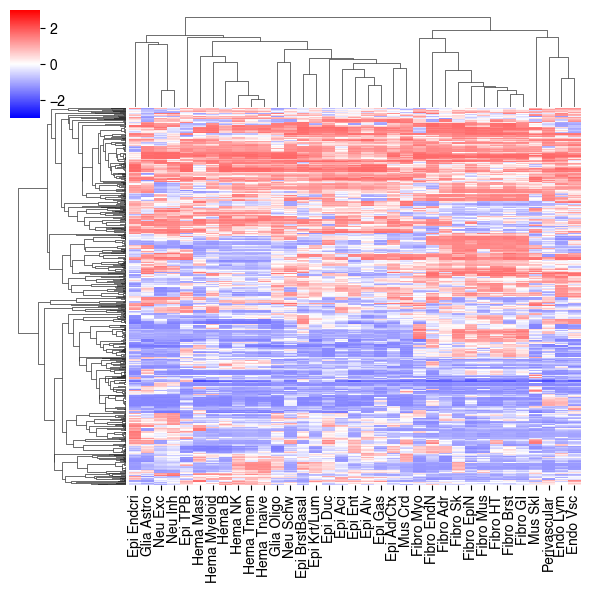

In [65]:
cg = sns.clustermap(tmp3c, cmap='bwr', vmin=-3, vmax=3, metric='cosine', figsize=(6,6), 
                    xticklabels=comp.columns.map(L1_annot), yticklabels=[])


In [61]:
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()

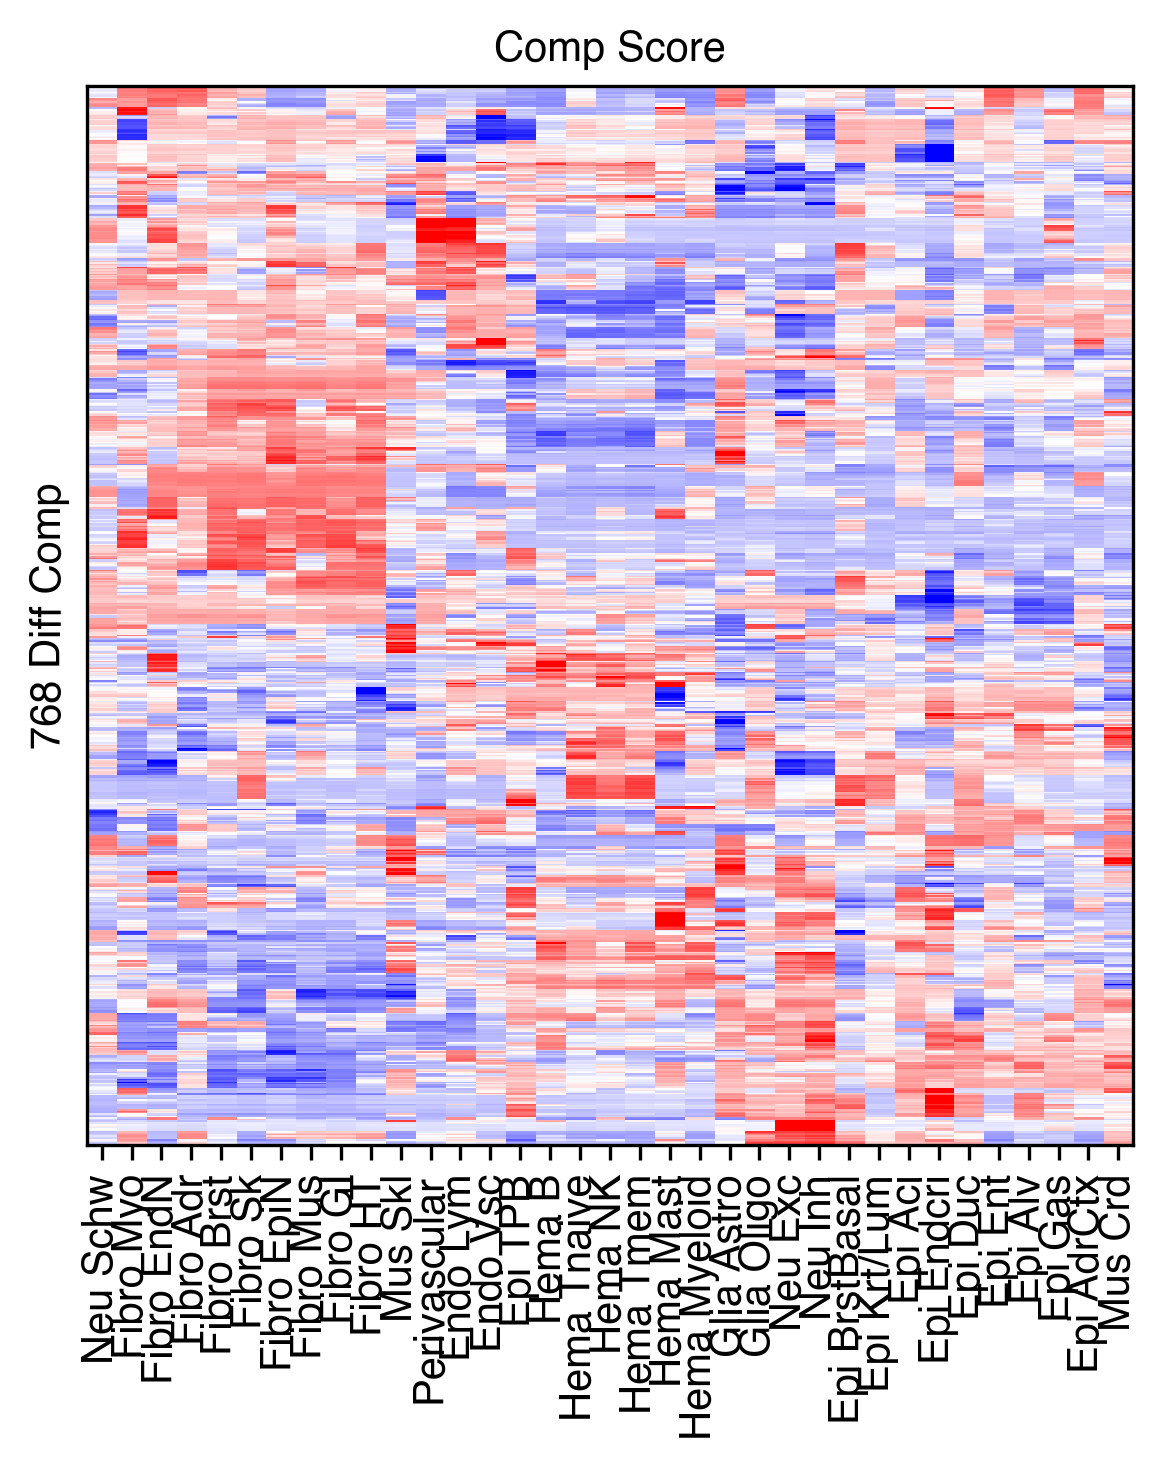

In [63]:
fig, ax = plt.subplots(figsize=(4, 5), dpi=300)

ax.imshow(tmp3c[np.ix_(rorder, corder)], cmap='bwr', aspect='auto', vmin=-3, vmax=3, interpolation='none')
ax.set_title('Comp Score', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(comp.shape[1]))
ax.set_xticklabels(comp.columns[corder].map(L1_meta['L1_abbr']), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{tmp3c.shape[0]} Diff Comp')

plt.tight_layout()


In [29]:
def compute_pearsonr(data_x, data_y):
    x_mean = np.mean(data_x, axis=1)
    y_mean = np.mean(data_y, axis=1)
    cov = np.sum((data_x - x_mean[:, None]) * (data_y - y_mean[:, None]), axis=1)
    stdlabel = np.sqrt(np.sum((data_x - x_mean[:, None]) ** 2, axis=1))
    stdpred = np.sqrt(np.sum((data_y - y_mean[:, None]) ** 2, axis=1))
    corr = cov / stdlabel / stdpred
    print(np.mean(corr))
    return corr


In [47]:
binall['mCG_corr'] = compute_pearsonr(comp.values, mcg.values)
binall['mCH_corr'] = compute_pearsonr(comp.values, mch.values)


0.012191405136921468
0.0054554775680507915


In [48]:
binall['logPadj'] = -np.log10(binall['padj'])
binall.loc[binall['logPadj']>300, 'logPadj'] = 300

/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [49]:
binall['mCG_std'] = np.std(mcg, axis=1)
binall['mCH_std'] = np.std(mch, axis=1)
binall['comp_std'] = np.std(comp, axis=1)
binall

,chr,start,end,sample_maha,pval,padj,mCG_corr,mCH_corr,logPadj,mCG_std,mCH_std,comp_std
chr1_19,chr1,1900000,2000000,0.113575,1.000000e+00,1.000000e+00,0.309247,0.377767,-0.000000,0.055201,0.009646,0.028466
chr1_20,chr1,2000000,2100000,2.330744,1.000000e+00,1.000000e+00,0.069742,0.238222,-0.000000,0.048166,0.007169,0.041597
chr1_21,chr1,2100000,2200000,1.324412,1.000000e+00,1.000000e+00,0.120032,0.077852,-0.000000,0.054712,0.003443,0.034441
chr1_28,chr1,2800000,2900000,1063.448956,2.391130e-201,3.589261e-201,-0.012764,0.167616,200.444995,0.123017,0.010848,0.283836
chr1_29,chr1,2900000,3000000,792.510638,1.490513e-144,2.159118e-144,-0.071177,0.179299,143.665724,0.129803,0.012099,0.266026
...,...,...,...,...,...,...,...,...,...,...,...,...
chr9_1369,chr9,136900000,137000000,0.089320,1.000000e+00,1.000000e+00,0.054787,-0.253586,-0.000000,0.034190,0.006216,0.069177
chr9_1370,chr9,137000000,137100000,0.374852,1.000000e+00,1.000000e+00,0.044765,-0.207306,-0.000000,0.034865,0.005395,0.077893
chr9_1371,chr9,137100000,137200000,4.112428,1.000000e+00,1.000000e+00,-0.020589,-0.193968,-0.000000,0.042190,0.002387,0.098444
chr9_1372,chr9,137200000,137300000,6.803561,9.999999e-01,1.000000e+00,-0.006165,-0.171149,-0.000000,0.049978,0.004447,0.103546


In [50]:
binall.to_hdf(f'{outdir}bin_stats.hdf', key='data')


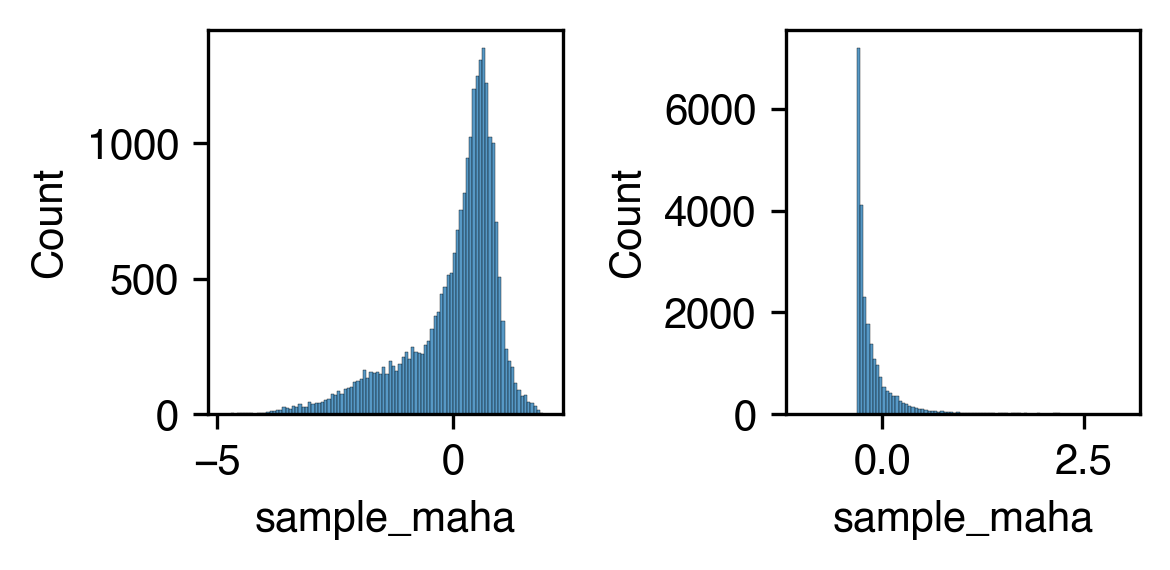

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300)
ax = axes[0]
sns.histplot(zscore(np.log10(binall['sample_maha'])), bins=100, ax=ax)
ax = axes[1]
sns.histplot(zscore(binall['sample_maha']), bins=100, binrange=(-1,3), ax=ax)
plt.tight_layout()


In [52]:
print(np.sum(zscore(binall['sample_maha'])>norm.isf(0.1)))


768


<Axes: xlabel='logPadj', ylabel='sample_maha'>

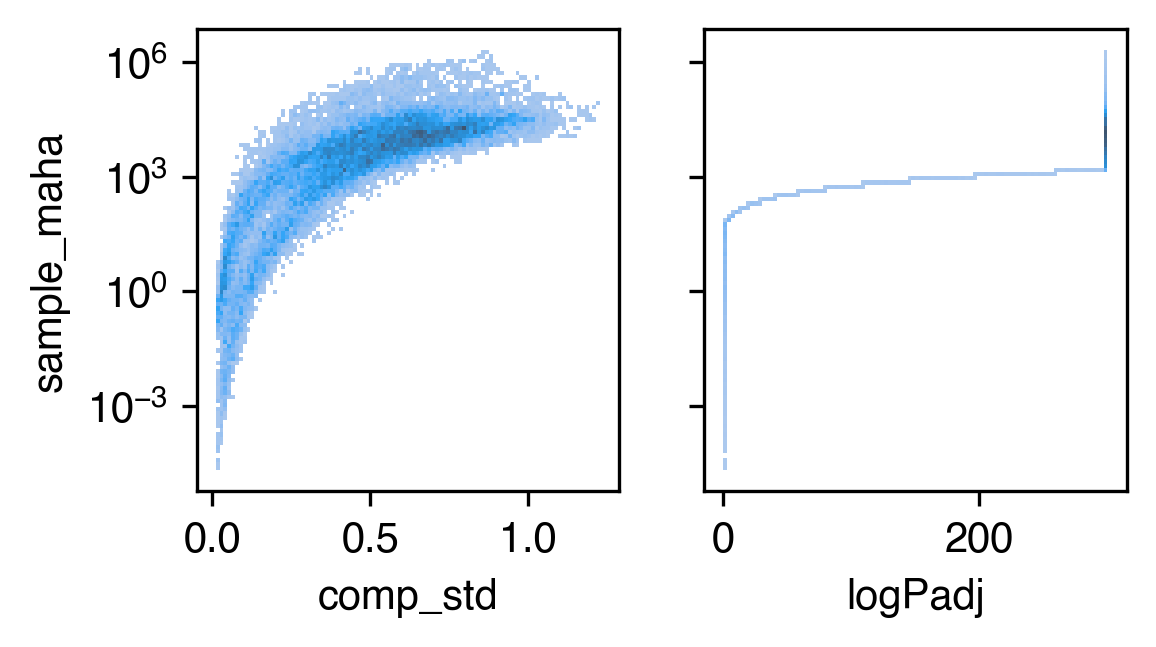

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(4,2), sharey='all', dpi=300)
ax = axes[0]
sns.histplot(binall, x='comp_std', y='sample_maha', bins=100, ax=ax, log_scale=(False, 10))
ax = axes[1]
sns.histplot(binall, x='logPadj', y='sample_maha', bins=100, ax=ax, log_scale=(False, 10))


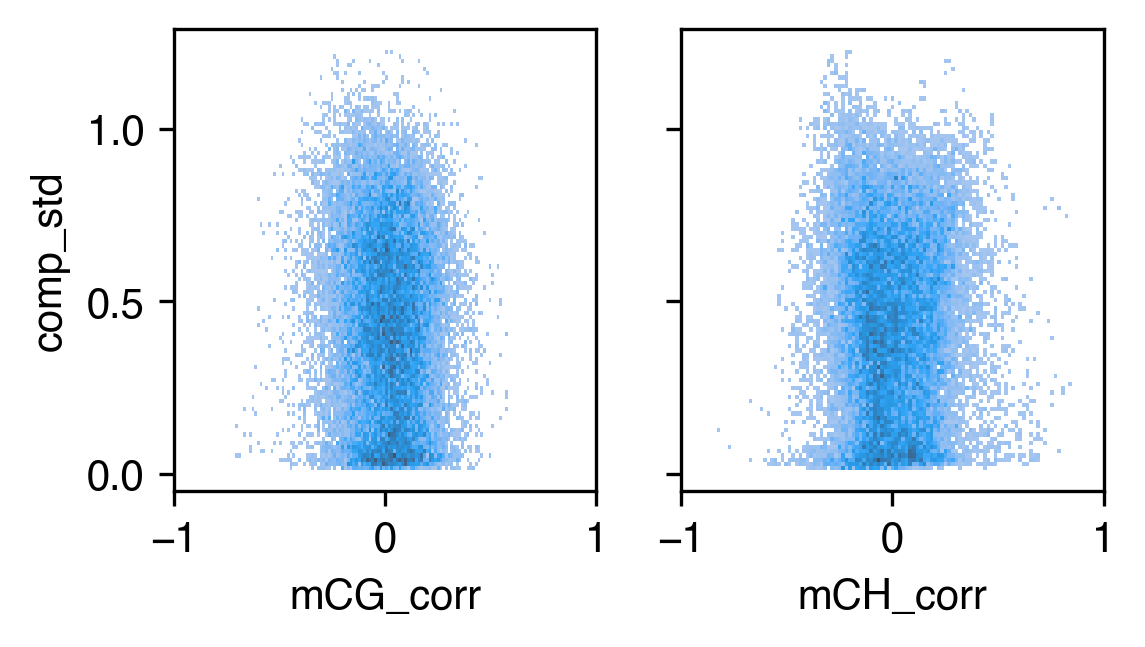

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(4,2), sharex='all', sharey='all', dpi=300)
ax = axes[0]
sns.histplot(binall, x='mCG_corr', y='comp_std', bins=100, ax=ax)
ax = axes[1]
sns.histplot(binall, x='mCH_corr', y='comp_std', bins=100, ax=ax)
ax.set_xticks([-1, 0, 1])
# plt.savefig(f'majortype_{group_name}_diffcomp_stdcorr.pdf', transparent=True)


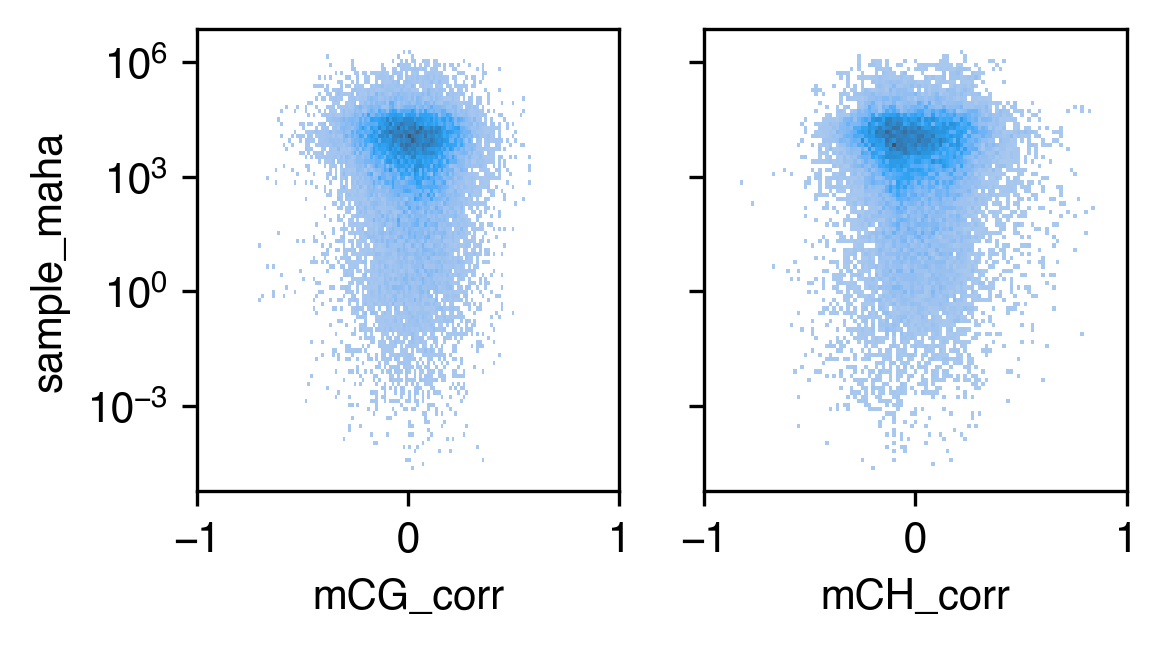

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(4,2), sharex='all', sharey='all', dpi=300)
ax = axes[0]
sns.histplot(binall, x='mCG_corr', y='sample_maha', bins=100, log_scale=(False, 10), ax=ax)
ax = axes[1]
sns.histplot(binall, x='mCH_corr', y='sample_maha', bins=100, log_scale=(False, 10), ax=ax)
ax.set_xticks([-1, 0, 1])
# plt.savefig(f'majortype_{group_name}_diffcomp_statscorr.pdf', transparent=True)
